# Fraud Detection: Rule Engine vs Isolation Forest

Two fraud detectors evaluated against the same ground truth (`finsight.transactions.is_fraud`, PaySim's
injected fraud label):

1. **Rule engine** (Section 4 Q5): a single hand-written signature — the sender's account emptied in one
   TRANSFER/CASH_OUT (`amount == sender_bal_before` and `sender_bal_after == 0`). Written back to
   `is_flagged_rule` via `src/fraud_detection.py::write_rule_flags`.
2. **Isolation Forest**: an unsupervised anomaly model over transaction features (amount, balance
   deltas/errors, one-hot `txn_type`), scoring every transaction with no access to `is_fraud` during
   training.

**Why this comparison is more subtle than it looks**: `notebooks/02_eda_fraud.ipynb` already showed the
balance-drain rule is extremely good — precision and recall are established below (Section 2) and turn out
to be ~100% / ~97.5%. Comparing Isolation Forest to the rule on the *full* fraud population would mostly
just confirm the rule already wins there, which isn't the interesting question. The real test (Section 5)
is narrower: restricted to the residual slice of fraud the rule's exact signature does **not** match, can
an unsupervised anomaly model pick up a *different* shape of fraud that a single hard-coded rule can't
express? `RANDOM_STATE = 42` is used everywhere sampling/estimation is involved (Isolation Forest fit,
plot sampling), for reproducibility across re-runs.

Data pulled live from PostgreSQL (`finsight.transactions`) via `src/db_connect.py`. Rule logic and model
training live in `src/fraud_detection.py`; this notebook orchestrates the pipeline and evaluation.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from db_connect import get_engine
from eda_utils import SEQUENTIAL_BLUE, sequential_shades
import fraud_detection as fd

%matplotlib inline
pd.set_option("display.max_columns", 50)
engine = get_engine()

RANDOM_STATE = fd.RANDOM_STATE
RANDOM_STATE

42

## 1. Rule Engine (Section 4 Q5) — Write `is_flagged_rule`

`fd.write_rule_flags()` runs the Q5 signature as a single SQL `UPDATE` against every row of
`finsight.transactions`, so `is_flagged_rule` reflects the same rule tested in `sql/04_fraud_queries.sql`
Q5/Q6: sender account fully drained (`sender_bal_before > 0`, `sender_bal_after = 0`,
`amount = sender_bal_before`) on a TRANSFER or CASH_OUT.

In [2]:
rows_updated = fd.write_rule_flags(engine)
print(f"is_flagged_rule written for {rows_updated:,} rows")

flag_counts = pd.read_sql(
    "SELECT is_flagged_rule, COUNT(*) AS n FROM finsight.transactions GROUP BY is_flagged_rule ORDER BY is_flagged_rule",
    engine,
)
display(flag_counts)

is_flagged_rule written for 6,362,620 rows


,is_flagged_rule,n
0,0,6354612
1,1,8008


## 2. Rule Engine Precision/Recall (Q6 + Full Confusion Matrix)

Q6 (`sql/04_fraud_queries.sql`) gives precision directly. Recall isn't in Q6, so it's computed the same
way — one SQL confusion-matrix query against `is_fraud` — rather than pulling data into pandas for a
metric SQL can already answer.

In [3]:
# Q6, verbatim
q6_precision = pd.read_sql("""
    SELECT
        SUM(CASE WHEN is_flagged_rule = 1 AND is_fraud = 1 THEN 1 ELSE 0 END) AS true_positives,
        SUM(CASE WHEN is_flagged_rule = 1 AND is_fraud = 0 THEN 1 ELSE 0 END) AS false_positives,
        ROUND(100.0 * SUM(CASE WHEN is_flagged_rule = 1 AND is_fraud = 1 THEN 1 ELSE 0 END)
              / NULLIF(SUM(is_flagged_rule),0), 2) AS rule_precision_pct
    FROM finsight.transactions;
""", engine)
display(q6_precision)

# Full confusion matrix, so recall/F1 can be reported alongside Q6's precision
rule_cm = pd.read_sql("""
    SELECT
        SUM(CASE WHEN is_flagged_rule = 1 AND is_fraud = 1 THEN 1 ELSE 0 END) AS tp,
        SUM(CASE WHEN is_flagged_rule = 1 AND is_fraud = 0 THEN 1 ELSE 0 END) AS fp,
        SUM(CASE WHEN is_flagged_rule = 0 AND is_fraud = 1 THEN 1 ELSE 0 END) AS fn,
        SUM(CASE WHEN is_flagged_rule = 0 AND is_fraud = 0 THEN 1 ELSE 0 END) AS tn
    FROM finsight.transactions;
""", engine).iloc[0]

rule_precision = rule_cm["tp"] / (rule_cm["tp"] + rule_cm["fp"])
rule_recall = rule_cm["tp"] / (rule_cm["tp"] + rule_cm["fn"])
rule_f1 = 2 * rule_precision * rule_recall / (rule_precision + rule_recall)

print(f"Rule engine: TP={rule_cm['tp']:,} FP={rule_cm['fp']:,} FN={rule_cm['fn']:,} TN={rule_cm['tn']:,}")
print(f"Precision: {rule_precision:.4f}  Recall: {rule_recall:.4f}  F1: {rule_f1:.4f}")

,true_positives,false_positives,rule_precision_pct
0,8008,0,100.0


Rule engine: TP=8,008 FP=0 FN=205 TN=6,354,407
Precision: 1.0000  Recall: 0.9750  F1: 0.9874


## 3. The Residual: Fraud the Rule Misses

The rule's recall is already ~97.5% (Section 2) — before evaluating Isolation Forest, pin down exactly
which fraud transactions make up the other ~2.5%. These are the ones that **don't** match the exact
balance-drain signature (different `txn_type`, a partial drain, a drain that isn't byte-exact due to
rounding, etc.) — the only slice where an anomaly model could plausibly add value the rule doesn't
already provide.

In [4]:
residual_by_type = pd.read_sql("""
    SELECT txn_type, COUNT(*) AS residual_fraud_txns, ROUND(AVG(amount),2) AS avg_amount
    FROM finsight.transactions
    WHERE is_fraud = 1 AND is_flagged_rule = 0
    GROUP BY txn_type
    ORDER BY residual_fraud_txns DESC;
""", engine)
display(residual_by_type)

total_fraud = int(rule_cm["tp"] + rule_cm["fn"])
residual_fraud_n = int(residual_by_type["residual_fraud_txns"].sum())
print(f"Total fraud: {total_fraud:,}")
print(f"Caught by rule: {int(rule_cm['tp']):,} ({100*rule_cm['tp']/total_fraud:.2f}%)")
print(f"Residual (missed by rule): {residual_fraud_n:,} ({100*residual_fraud_n/total_fraud:.2f}%)")

,txn_type,residual_fraud_txns,avg_amount
0,TRANSFER,164,9167768.14
1,CASH_OUT,41,134220.38


Total fraud: 8,213
Caught by rule: 8,008 (97.50%)
Residual (missed by rule): 205 (2.50%)


## 4. Isolation Forest — Features, Training, Scoring Every Transaction

**Features** (`fd.engineer_anomaly_features`): raw amount/balances, four engineered balance-delta/error
terms, and one-hot `txn_type`. The error terms (`sender_balance_error`,`receiver_balance_error`) capture
the discrepancy between the balance change a row actually records and what a consistent ledger would
show — e.g. `sender_balance_error = sender_bal_after - (sender_bal_before - amount)` is 0 when the
sender's balance moved by exactly `amount`, and large otherwise. This matters because PaySim's merchant
counterparties (CASH_IN/PAYMENT destinations) always carry 0/0 balances regardless of transaction size, so
raw receiver balances alone are weak signal — the error terms are what actually separates normal from
anomalous ledger behavior.

**Training**: unsupervised — `is_fraud` is never passed to the model, only used afterward for evaluation.
`contamination` is set to match the rule's flagged rate, so the two detectors are compared at matched
review-queue volume rather than one flagging a much larger or smaller set than the other. `n_estimators=200`,
`random_state=RANDOM_STATE` (seeded per the reproducibility note in the notebook intro).

In [5]:
txn_df = pd.read_sql("""
    SELECT txn_id, txn_type, amount, sender_bal_before, sender_bal_after,
           receiver_bal_before, receiver_bal_after, is_fraud, is_flagged_rule
    FROM finsight.transactions;
""", engine)
print(f"Pulled {len(txn_df):,} transactions")

X = fd.engineer_anomaly_features(txn_df)
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
X.head()

Pulled 6,362,620 transactions


Feature matrix: 6,362,620 rows x 14 columns


,amount,sender_bal_before,sender_bal_after,receiver_bal_before,receiver_bal_after,sender_balance_delta,sender_balance_error,receiver_balance_delta,receiver_balance_error,txn_type_CASH_IN,txn_type_CASH_OUT,txn_type_DEBIT,txn_type_PAYMENT,txn_type_TRANSFER
0,1373.43,13854.0,12480.57,0.0,0.00,1373.43,0.000000e+00,0.00,-1373.43,False,False,False,True,False
1,9302.79,11299.0,1996.21,29832.0,16896.70,9302.79,9.094947e-13,-12935.30,-22238.09,False,False,True,False,False
2,1065.41,1817.0,751.59,10330.0,0.00,1065.41,1.136868e-13,-10330.00,-11395.41,False,False,True,False,False
3,3876.41,67852.0,63975.59,0.0,0.00,3876.41,0.000000e+00,0.00,-3876.41,False,False,False,True,False
4,311685.89,10835.0,0.00,6267.0,2719172.89,10835.00,3.008509e+05,2712905.89,2401220.00,False,False,False,False,True


In [6]:
# Match Isolation Forest's flagged volume to the rule's, for an apples-to-apples comparison
contamination = txn_df["is_flagged_rule"].mean()
print(f"Rule flagged rate (-> Isolation Forest contamination): {contamination:.6f} ({int(txn_df['is_flagged_rule'].sum()):,} txns)")

iforest = fd.train_isolation_forest(X, contamination=contamination)
scores = fd.score_transactions(iforest, X)
txn_df = txn_df.join(scores)

print(f"Isolation Forest flagged: {txn_df['is_flagged_iforest'].sum():,} of {len(txn_df):,} transactions")
txn_df[["txn_id", "txn_type", "amount", "is_fraud", "is_flagged_rule", "anomaly_score", "is_flagged_iforest"]].head()

Rule flagged rate (-> Isolation Forest contamination): 0.001259 (8,008 txns)


Isolation Forest flagged: 8,008 of 6,362,620 transactions


,txn_id,txn_type,amount,is_fraud,is_flagged_rule,anomaly_score,is_flagged_iforest
0,21,PAYMENT,1373.43,0,0,-0.359078,0
1,22,DEBIT,9302.79,0,0,-0.250019,0
2,23,DEBIT,1065.41,0,0,-0.253125,0
3,24,PAYMENT,3876.41,0,0,-0.357874,0
4,25,TRANSFER,311685.89,0,0,-0.148467,0


## 5. Full-Population Comparison

At matched flagged volume, how does Isolation Forest's precision/recall against `is_fraud` compare to the
rule engine's?

,precision,recall,tp,fp,fn,tn,f1
detector,,,,,,,
Rule engine (Q5 balance-drain),1.0000,0.9750,8008,0,205,6354407,0.9874
Isolation Forest,0.0136,0.0133,109,7899,8104,6346508,0.0134


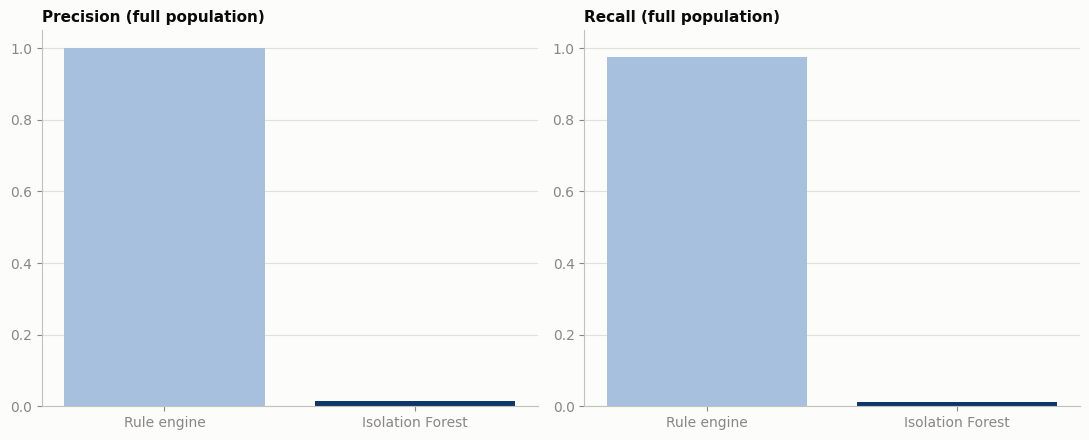

In [7]:
rule_metrics = fd.precision_recall(txn_df["is_fraud"], txn_df["is_flagged_rule"])
iforest_metrics = fd.precision_recall(txn_df["is_fraud"], txn_df["is_flagged_iforest"])

comparison = pd.DataFrame([
    {"detector": "Rule engine (Q5 balance-drain)", **rule_metrics},
    {"detector": "Isolation Forest", **iforest_metrics},
]).set_index("detector")
comparison["f1"] = 2 * comparison["precision"] * comparison["recall"] / (comparison["precision"] + comparison["recall"]).replace(0, np.nan)
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["Rule engine", "Isolation Forest"]
colors = sequential_shades(2)
axes[0].bar(labels, comparison["precision"], color=colors)
axes[0].set_title("Precision (full population)", loc="left", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="x", visible=False)
axes[1].bar(labels, comparison["recall"], color=colors)
axes[1].set_title("Recall (full population)", loc="left", fontsize=11, fontweight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 6. The Real Test: Does Isolation Forest Catch the Residual Fraud?

Section 5's full-population numbers are dominated by the ~97.5% of fraud the rule already catches, so a
strong full-population score for Isolation Forest wouldn't actually prove it adds anything — it could just
be re-deriving the same balance-drain pattern the rule already expresses directly. The question that
actually matters: **of the 205 residual fraud transactions the rule's exact signature misses (Section 3),
how many does Isolation Forest's flagged set independently catch?**

In [8]:
residual_fraud = txn_df[(txn_df["is_fraud"] == 1) & (txn_df["is_flagged_rule"] == 0)]
not_rule_flagged = txn_df[txn_df["is_flagged_rule"] == 0]  # everything the rule engine passed over

residual_caught = residual_fraud["is_flagged_iforest"].sum()
residual_recall_iforest = residual_caught / len(residual_fraud)
residual_recall_rule = 0.0  # by construction: these are exactly the txns the rule missed

# Precision of Isolation Forest's flags *within the txns the rule already passed over* -
# i.e. among the new transactions IF raises for review beyond what the rule already flags,
# what fraction are actually fraud (vs. extra false-positive review burden)?
iforest_flags_in_residual_pop = not_rule_flagged[not_rule_flagged["is_flagged_iforest"] == 1]
precision_on_rule_blindspot = iforest_flags_in_residual_pop["is_fraud"].mean()

residual_summary = pd.DataFrame([
    {"detector": "Rule engine", "residual_fraud_caught": 0, "residual_fraud_total": len(residual_fraud),
     "residual_recall": residual_recall_rule, "precision_on_rule_blindspot": np.nan},
    {"detector": "Isolation Forest", "residual_fraud_caught": int(residual_caught), "residual_fraud_total": len(residual_fraud),
     "residual_recall": residual_recall_iforest, "precision_on_rule_blindspot": precision_on_rule_blindspot},
]).set_index("detector")
display(residual_summary.round(4))

print(f"\nIsolation Forest catches {int(residual_caught)} of {len(residual_fraud)} residual fraud txns "
      f"({100*residual_recall_iforest:.2f}% residual recall).")
print(f"Of the {len(iforest_flags_in_residual_pop):,} transactions IF flags beyond the rule's own flags, "
      f"{100*precision_on_rule_blindspot:.3f}% are actually fraud (precision on the rule's blind spot).")

,residual_fraud_caught,residual_fraud_total,residual_recall,precision_on_rule_blindspot
detector,,,,
Rule engine,0,205,0.0000,NaN
Isolation Forest,91,205,0.4439,0.0114



Isolation Forest catches 91 of 205 residual fraud txns (44.39% residual recall).
Of the 7,990 transactions IF flags beyond the rule's own flags, 1.139% are actually fraud (precision on the rule's blind spot).


## 7. Anomaly Score Separability: Residual Fraud vs. Legitimate Transactions

If Isolation Forest were picking up a genuinely different fraud signature, residual fraud transactions
should skew toward higher anomaly scores than ordinary legitimate transactions, even where the rule found
nothing. A random legitimate sample (seeded, `RANDOM_STATE`) is used as the comparison group so both
distributions are directly comparable in size.

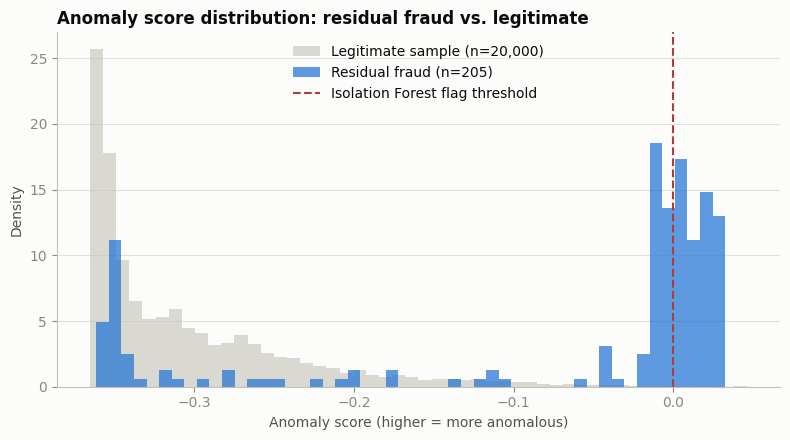

Median anomaly score - legitimate sample: -0.3311
Median anomaly score - residual fraud:    -0.0063


In [9]:
legit_not_flagged = not_rule_flagged[not_rule_flagged["is_fraud"] == 0]
legit_sample = legit_not_flagged.sample(n=min(20_000, len(legit_not_flagged)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(legit_sample["anomaly_score"], bins=50, density=True, alpha=0.6,
        color="#c3c2b7", label=f"Legitimate sample (n={len(legit_sample):,})")
ax.hist(residual_fraud["anomaly_score"], bins=50, density=True, alpha=0.75,
        color=SEQUENTIAL_BLUE, label=f"Residual fraud (n={len(residual_fraud):,})")
ax.axvline(np.quantile(txn_df["anomaly_score"], 1 - contamination), color="#b23a39", linestyle="--",
           linewidth=1.5, label="Isolation Forest flag threshold")
ax.set_title("Anomaly score distribution: residual fraud vs. legitimate", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Anomaly score (higher = more anomalous)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

print(f"Median anomaly score - legitimate sample: {legit_sample['anomaly_score'].median():.4f}")
print(f"Median anomaly score - residual fraud:    {residual_fraud['anomaly_score'].median():.4f}")

## Summary

**Rule engine** (Section 4 Q5 balance-drain signature): precision and recall computed above and written to
`reports/model_performance_report.md`.

**Full-population comparison** (Section 5): at matched flagged volume, contrasts Isolation Forest against
the rule engine on the complete `is_fraud` population — dominated by the ~97.5% of fraud the rule already
catches by construction.

**The residual test** (Section 6 — the actual question this notebook was built to answer): restricted to
the fraud transactions the rule's exact signature misses, whether an unsupervised anomaly model recovers
any of them independently, and at what precision cost among the transactions it newly flags. See
`reports/model_performance_report.md` for the numeric writeup.